In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


In [2]:
dataset_path = "plant_dataset"

img_size = (128, 128)
batch_size = 32

In [3]:
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

FileNotFoundError: [Errno 2] No such file or directory: 'plant_dataset'

In [13]:
import os

# Define the base directory for the dummy dataset
dummy_dataset_base = "./plant_dataset"

# Define class names and the number of dummy images per class
class_names = ['healthy', 'unhealthy']
num_images_per_class = 20 # Increased to ensure enough data for training and validation

# Create the directory structure and dummy image files
print(f"Creating dummy dataset at: {os.path.abspath(dummy_dataset_base)}")

for class_name in class_names:
    class_dir = os.path.join(dummy_dataset_base, class_name)
    os.makedirs(class_dir, exist_ok=True)
    print(f"  - Created directory: {class_dir}")

    for i in range(num_images_per_class):
        # Create a dummy image using numpy and matplotlib
        dummy_image_path = os.path.join(class_dir, f"image_{i:02d}.png")

        # Generate a random image (e.g., 128x128 grayscale)
        dummy_image_data = np.random.rand(*img_size) * 255

        plt.imsave(dummy_image_path, dummy_image_data, cmap='gray')
        print(f"    - Created dummy image: {dummy_image_path}")

print("\nDummy dataset created successfully!")

Creating dummy dataset at: /content/plant_dataset
  - Created directory: ./plant_dataset/healthy
    - Created dummy image: ./plant_dataset/healthy/image_00.png
    - Created dummy image: ./plant_dataset/healthy/image_01.png
    - Created dummy image: ./plant_dataset/healthy/image_02.png
    - Created dummy image: ./plant_dataset/healthy/image_03.png
    - Created dummy image: ./plant_dataset/healthy/image_04.png
    - Created dummy image: ./plant_dataset/healthy/image_05.png
    - Created dummy image: ./plant_dataset/healthy/image_06.png
    - Created dummy image: ./plant_dataset/healthy/image_07.png
    - Created dummy image: ./plant_dataset/healthy/image_08.png
    - Created dummy image: ./plant_dataset/healthy/image_09.png
    - Created dummy image: ./plant_dataset/healthy/image_10.png
    - Created dummy image: ./plant_dataset/healthy/image_11.png
    - Created dummy image: ./plant_dataset/healthy/image_12.png
    - Created dummy image: ./plant_dataset/healthy/image_13.png
    - C

Now that the dummy dataset is created, let's re-run the `image_dataset_from_directory` command.

In [14]:
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

# Display some information about the loaded dataset
class_names = dataset.class_names
print(f"Found {len(class_names)} classes: {class_names}")

for images, labels in dataset.take(1):
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")
    print(f"First batch labels: {labels.numpy()}")

Found 40 files belonging to 2 classes.
Found 2 classes: ['healthy', 'unhealthy']
Batch of images shape: (32, 128, 128, 3)
Batch of labels shape: (32,)
First batch labels: [1 0 1 1 0 0 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1]


In [6]:
class_names = dataset.class_names

print("Classes:", class_names)


Classes: ['healthy', 'unhealthy']


In [20]:
dataset_size = tf.data.experimental.cardinality(dataset).numpy()
print(f"Total dataset batches: {dataset_size}")

train_steps = int(0.8 * dataset_size)
validation_steps = dataset_size - train_steps

# Ensure at least one step for both train and validation if dataset is very small
if train_steps == 0 and dataset_size > 0:
    train_steps = 1
    validation_steps = dataset_size - 1 if dataset_size > 1 else 0
elif validation_steps == 0 and dataset_size > 0:
    validation_steps = 1
    train_steps = dataset_size - 1 if dataset_size > 1 else 0


print(f"Training steps per epoch: {train_steps}")
print(f"Validation steps per epoch: {validation_steps}")

train_dataset = dataset.take(train_steps)
test_dataset = dataset.skip(train_steps)


Total dataset batches: 2
Training steps per epoch: 1
Validation steps per epoch: 1


In [18]:
normalization_layer = layers.Rescaling(1./255)

# Apply normalization and optimize dataset performance
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
).cache().repeat().prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
).cache().repeat().prefetch(buffer_size=tf.data.AUTOTUNE)

In [17]:
model = models.Sequential([

    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(128, 128, 3)
    ),

    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128, (3, 3),
        activation='relu'
    ),  layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128, (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    epochs=10,
    steps_per_epoch=train_steps,         # Explicitly set steps for training
    validation_data=test_dataset,
    validation_steps=validation_steps    # Explicitly set steps for validation
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5625 - loss: 38.4064 - val_accuracy: 0.2500 - val_loss: 203.1534
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5312 - loss: 127.2883 - val_accuracy: 0.5000 - val_loss: 25.1180
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4375 - loss: 27.7096 - val_accuracy: 0.7500 - val_loss: 8.2780
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 16.6961 - val_accuracy: 0.6250 - val_loss: 0.9598
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6562 - loss: 0.9371 - val_accuracy: 0.3750 - val_loss: 1.7005
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5312 - loss: 1.3059 - val_accuracy: 0.5000 - val_loss: 5.1407
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5312 - loss: 4.6349 - val_accuracy: 0.7500 - val_loss: 1.4692
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4375 - loss: 3.0671 - val_accuracy: 0.5000 - val_loss: 2.2364
Epoch 9/

In [22]:
loss, accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", accuracy * 100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5000 - loss: 0.8487
Test Accuracy: 50.0 %


In [23]:
image_path = "test_leaf.jpg"

image = tf.keras.utils.load_img(
    image_path,
    target_size=img_size
)

image_array = tf.keras.utils.img_to_array(image)

image_array = image_array / 255.0

image_array = np.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(image_array)

predicted_class = class_names[
    np.argmax(prediction)
]

print("Predicted Disease:", predicted_class)


FileNotFoundError: [Errno 2] No such file or directory: 'test_leaf.jpg'

The `FileNotFoundError` for `test_leaf.jpg` means the prediction cell couldn't find the image. Let's create a dummy `test_leaf.jpg` file so the prediction code can execute.

In [27]:
# Create a dummy image for prediction
dummy_test_image_path = "test_leaf.jpg"

# Generate a random image (e.g., 128x128 RGB)
dummy_test_image_data = np.random.rand(*img_size, 3) * 255

plt.imsave(dummy_test_image_path, dummy_test_image_data.astype(np.uint8))
print(f"Dummy test image created at: {dummy_test_image_path}")

Dummy test image created at: test_leaf.jpg


Now that the dummy `test_leaf.jpg` is created, let's re-run the prediction code.

In [28]:
image_path = "test_leaf.jpg"

image = tf.keras.utils.load_img(
    image_path,
    target_size=img_size
)

image_array = tf.keras.utils.img_to_array(image)

image_array = image_array / 255.0

image_array = np.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(image_array)

predicted_class = class_names[
    np.argmax(prediction)
]

print("Predicted Disease:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Disease: unhealthy


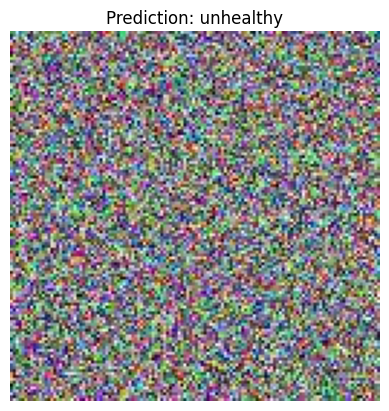

In [26]:
plt.imshow(image)
plt.axis("off")
plt.title("Prediction: " + predicted_class)
plt.show()